In [30]:
import os 
import pandas as pd
import numpy as np
import matplotlib as plt
plt.rcParams['font.sans-serif'] = 'SimHei'

In [59]:
data = pd.read_csv('data_wuliu.csv',encoding='gbk')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1161 entries, 0 to 1160
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   订单号     1159 non-null   object 
 1   订单行     1161 non-null   int64  
 2   销售时间    1161 non-null   object 
 3   交货时间    1161 non-null   object 
 4   货品交货状况  1159 non-null   object 
 5   货品      1161 non-null   object 
 6   货品用户反馈  1161 non-null   object 
 7   销售区域    1161 non-null   object 
 8   数量      1157 non-null   float64
 9   销售金额    1161 non-null   object 
dtypes: float64(1), int64(1), object(8)
memory usage: 90.8+ KB


# 通过info()可以看出，包括10列数据，名字，数据量，格式等，可以得出：
# 1.订单号，货品交货情况，数量：存在缺失值，但是确实量不大，可以删除
# 2.订单行，对分析无关紧要，可以考虑删除
# 3.销售格式不对（万元|元，逗号问题），数据类型需要转换成int|float

In [60]:
data.drop_duplicates(keep='first',inplace=True)
data.dropna(axis=0,how='any',inplace=True)
data.drop(columns=['订单行'],inplace=True,axis=1)
print(data.info())
data.reset_index(drop=True,inplace=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1146 entries, 0 to 1160
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   订单号     1146 non-null   object 
 1   销售时间    1146 non-null   object 
 2   交货时间    1146 non-null   object 
 3   货品交货状况  1146 non-null   object 
 4   货品      1146 non-null   object 
 5   货品用户反馈  1146 non-null   object 
 6   销售区域    1146 non-null   object 
 7   数量      1146 non-null   float64
 8   销售金额    1146 non-null   object 
dtypes: float64(1), object(8)
memory usage: 89.5+ KB
None


In [14]:
#取出销售金额列，对每个数据进行清洗
#编写自定义过滤函数：删除逗号，转成float,如果是万元则*10000，否则，删除元

In [61]:
def data_deal(number):
    if number.find('万元')!= -1:
        number_new = float(number[:number.find('万元')].replace(',',''))*10000
        pass
    else:
        number_new = float(number.replace('元','').replace(',',''))
        pass
    return number_new
data['销售金额'] = data['销售金额'].map(data_deal)
data

,订单号,销售时间,交货时间,货品交货状况,货品,货品用户反馈,销售区域,数量,销售金额
0,P096311,2016-7-30,2016-9-30,晚交货,货品3,质量合格,华北,2.0,105275.0
1,P096826,2016-8-30,2016-10-30,按时交货,货品3,质量合格,华北,10.0,11500000.0
2,P097435,2016-7-30,2016-9-30,按时交货,货品1,返修,华南,2.0,685877.0
3,P097446,2016-11-26,2017-1-26,晚交货,货品3,质量合格,华北,15.0,12958.0
4,P097446,2016-11-26,2017-1-26,晚交货,货品3,拒货,华北,15.0,3239.0
...,...,...,...,...,...,...,...,...,...
1141,P299901,2016-12-15,2017-3-15,按时交货,货品6,质量合格,马来西亚,2.0,20041.0
1142,P302956,2016-12-22,2017-3-22,按时交货,货品2,拒货,华东,20.0,7944.0
1143,P303801,2016-12-15,2017-3-15,按时交货,货品2,质量合格,华东,1.0,19408.0
1144,P307276,2016-12-22,2017-3-22,按时交货,货品6,质量合格,马来西亚,1.0,3218.0


In [65]:
data.describe()

,销售时间,数量,销售金额,月份
count,1145,1145.000000,1.145000e+03,1145.000000
mean,2016-09-28 19:30:51.877729280,76.134934,1.224557e+05,9.310917
min,2016-07-01 00:00:00,1.000000,5.100000e+01,7.000000
25%,2016-08-15 00:00:00,1.000000,2.946000e+03,8.000000
50%,2016-09-30 00:00:00,1.000000,9.486000e+03,9.000000
75%,2016-11-05 00:00:00,4.000000,3.577300e+04,11.000000
max,2016-12-30 00:00:00,11500.000000,3.270000e+07,12.000000
std,NaN,589.669861,1.115081e+06,1.672305


In [66]:
#1.销售金额==0，采用删除方法，因为数据量很小
data = data[data['销售金额']!=0]
data.describe()
#2.销售金额和数量存在严重右偏现象，在电商领域2|8很正常，无需处理

,销售时间,数量,销售金额,月份
count,1145,1145.000000,1.145000e+03,1145.000000
mean,2016-09-28 19:30:51.877729280,76.134934,1.224557e+05,9.310917
min,2016-07-01 00:00:00,1.000000,5.100000e+01,7.000000
25%,2016-08-15 00:00:00,1.000000,2.946000e+03,8.000000
50%,2016-09-30 00:00:00,1.000000,9.486000e+03,9.000000
75%,2016-11-05 00:00:00,4.000000,3.577300e+04,11.000000
max,2016-12-30 00:00:00,11500.000000,3.270000e+07,12.000000
std,NaN,589.669861,1.115081e+06,1.672305


In [101]:
data['销售时间']=pd.to_datetime(data['销售时间'])
data['月份']=data['销售时间'].apply(lambda x:x.month)
data

,订单号,销售时间,交货时间,货品交货状况,货品,货品用户反馈,销售区域,数量,销售金额,月份
0,P096311,2016-07-30,2016-9-30,晚交货,货品3,质量合格,华北,2.0,105275.0,7
1,P096826,2016-08-30,2016-10-30,按时交货,货品3,质量合格,华北,10.0,11500000.0,8
2,P097435,2016-07-30,2016-9-30,按时交货,货品1,返修,华南,2.0,685877.0,7
3,P097446,2016-11-26,2017-1-26,晚交货,货品3,质量合格,华北,15.0,12958.0,11
4,P097446,2016-11-26,2017-1-26,晚交货,货品3,拒货,华北,15.0,3239.0,11
...,...,...,...,...,...,...,...,...,...,...
1141,P299901,2016-12-15,2017-3-15,按时交货,货品6,质量合格,马来西亚,2.0,20041.0,12
1142,P302956,2016-12-22,2017-3-22,按时交货,货品2,拒货,华东,20.0,7944.0,12
1143,P303801,2016-12-15,2017-3-15,按时交货,货品2,质量合格,华东,1.0,19408.0,12
1144,P307276,2016-12-22,2017-3-22,按时交货,货品6,质量合格,马来西亚,1.0,3218.0,12


# 三、数据分析并可视化
# 1.配送服务是否存在问题
# a.月份维度

In [72]:
data['货品交货状况'] = data['货品交货状况'].str.strip()
data1 = data.groupby(['月份','货品交货状况']).size().unstack()
data1['按时交货率']=data1['按时交货']/((data1['按时交货'])+(data1['晚交货']))
data1
#从按时交货率来看，第四季度低于第三季度，猜测可能是气候原因

货品交货状况,按时交货,晚交货,按时交货率
月份,,,
7,189,13,0.935644
8,218,35,0.861660
9,122,9,0.931298
10,238,31,0.884758
11,101,25,0.801587
12,146,18,0.890244


# b.销售区域维度

In [74]:
data1 = data.groupby(['销售区域','货品交货状况']).size().unstack()
data1['按时交货率']=data1['按时交货']/((data1['按时交货'])+(data1['晚交货']))
print(data1.sort_values(by='按时交货率',ascending=False))
#西北地区存在突出的延迟交货问题

货品交货状况  按时交货  晚交货     按时交货率
销售区域                       
泰国       183    4  0.978610
马来西亚     310   16  0.950920
华南        10    1  0.909091
华北       226   27  0.893281
华东       268   39  0.872964
西北        17   44  0.278689


# c.货品维度

In [76]:
data1 = data.groupby(['货品','货品交货状况']).size().unstack()
data1['按时交货率']=data1['按时交货']/((data1['按时交货'])+(data1['晚交货']))
print(data1.sort_values(by='按时交货率',ascending=False))
# 货品4晚交货情况非常严重，其余货品相对较好

货品交货状况  按时交货  晚交货     按时交货率
货品                         
货品5      183    4  0.978610
货品6      309    7  0.977848
货品1       27    2  0.931034
货品3      212   26  0.890756
货品2      269   48  0.848580
货品4       14   44  0.241379


# d.货品和销售区域结合

In [78]:
data1 = data.groupby(['货品','销售区域','货品交货状况']).size().unstack()
data1['按时交货率']=data1['按时交货']/((data1['按时交货'])+(data1['晚交货']))
print(data1.sort_values(by='按时交货率',ascending=False))
#销售区域：最差在西北地区，货品有1和4，主要是货品4送的太晚导致
#货品：最差的货品2，主要送往华东和马来西亚，主要是马来西亚送货较晚导致的

货品交货状况     按时交货   晚交货     按时交货率
货品  销售区域                       
货品5 泰国    183.0   4.0  0.978610
货品6 马来西亚  309.0   7.0  0.977848
货品1 华北     14.0   1.0  0.933333
    华南     10.0   1.0  0.909091
货品3 华北    212.0  26.0  0.890756
货品2 华东    268.0  39.0  0.872964
货品4 西北     14.0  44.0  0.241379
货品2 马来西亚    1.0   9.0  0.100000
货品1 西北      3.0   NaN       NaN


# 2.是否存在尚有潜力的销售地区

# a.月份维度

<Axes: xlabel='月份'>

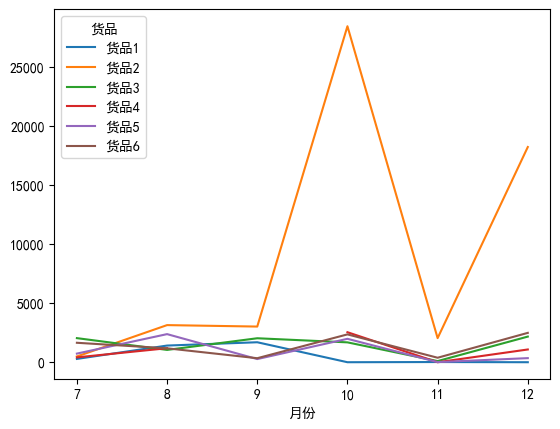

In [94]:
data1 = data.groupby(['月份','货品'])['数量'].sum().unstack()
data1.plot(kind='line')
# 货品2在10月和12月销量猛增，原因猜测有二：1.公司加大营销力度 2.开发了新市场(后续证伪)

# b.不同区域

In [91]:
data1 = data.groupby(['销售区域','货品'])['数量'].sum().unstack()
data1
# 从销售区域看，每种货品销售区域为1~3个，货品1有3个销售区域，其余均为1个

货品,货品1,货品2,货品3,货品4,货品5,货品6
销售区域,,,,,,
华东,NaN,53811.0,NaN,NaN,NaN,NaN
华北,2827.0,NaN,9073.5,NaN,NaN,NaN
华南,579.0,NaN,NaN,NaN,NaN,NaN
泰国,NaN,NaN,NaN,NaN,5733.0,NaN
西北,11.0,NaN,NaN,5229.0,NaN,NaN
马来西亚,NaN,1510.0,NaN,NaN,NaN,8401.0


# c.月份和区域

In [96]:
data1 = data.groupby(['月份','销售区域','货品'])['数量'].sum().unstack()
data1['货品2']
# 货品2在10，12月销量猛增，原因主要发生在原有的销售区域（华东）
#同样，分析出在7，8，9，11月份销售数量还有很大提升空间，可以适当加大营销力度

月份  销售区域
7   华东        489.0
    华北          NaN
    华南          NaN
    泰国          NaN
    西北          NaN
    马来西亚        2.0
8   华东       1640.0
    华北          NaN
    华南          NaN
    泰国          NaN
    西北          NaN
    马来西亚     1503.0
9   华东       3019.0
    华北          NaN
    华南          NaN
    泰国          NaN
    西北          NaN
    马来西亚        1.0
10  华东      28420.0
    华北          NaN
    泰国          NaN
    西北          NaN
    马来西亚        NaN
11  华东       2041.0
    华北          NaN
    华南          NaN
    泰国          NaN
    西北          NaN
    马来西亚        1.0
12  华东      18202.0
    华北          NaN
    华南          NaN
    泰国          NaN
    西北          NaN
    马来西亚        3.0
Name: 货品2, dtype: float64

# 3.商品是否存在质量问题

In [113]:
data['货品用户反馈'] = data['货品用户反馈'].str.strip()
data1 = data.groupby(['货品','销售区域'])['货品用户反馈'].value_counts().unstack()
data1['拒货率']= data1['拒货']/data1.sum(axis=1)
data1['返修率']= data1['返修']/data1.sum(axis=1)
data1['合格率']= data1['质量合格']/data1.sum(axis=1)
data1.sort_values(['合格率','返修率','拒货率'],ascending=False)

货品用户反馈      拒货   质量合格    返修       拒货率       返修率       合格率
货品  销售区域                                                 
货品3 华北    31.0  188.0  19.0  0.130252  0.079788  0.789219
货品6 马来西亚  56.0  246.0  14.0  0.177215  0.044279  0.777936
货品5 泰国    14.0  144.0  29.0  0.074866  0.155018  0.769108
货品2 华东    72.0  184.0  51.0  0.234528  0.165997  0.598568
货品1 华南     5.0    4.0   2.0  0.454545  0.174603  0.343963
    西北     NaN    1.0   2.0       NaN  0.666667  0.272727
    华北     NaN    3.0  12.0       NaN  0.800000  0.189873
货品4 西北     NaN    9.0  49.0       NaN  0.844828  0.152945
货品2 马来西亚   6.0    1.0   3.0  0.600000  0.283019  0.091886

In [114]:
# 货品3,6,5合格率较低，返修率较低，说明质量还可以
# 货品1,2,4合格率较低，返修率较高，质量存在一些问题，需要改善
# 货品2在马来西亚的拒货率最高，同事货品2在马来西亚的按时交货率也很低。猜测马来用户对送货时效性要求高
# 如果达不到就会选择拒货
# 货品2在华东地区销量大，可以考虑加大在华东投资，适当减小马来西亚的投入